# Debugging Opening Triangulation Failures

Dieses Notebook zeigt an einem problematischen Fall Schritt fuer Schritt:

1. wie das gespeicherte schlechte Opening aussieht
2. wie der Ostium-Ring in 3D und in 2D aussieht
3. welche geometrischen Warnsignale der Ring hat
4. wie die aktuelle balancierte Triangulation arbeitet
5. wann Ear-Clipping oder der explizite Fan-Fallback einspringen

Empfohlene Umgebung: `conda activate aneug` oder `conda run -n aneug jupyter lab`.


In [8]:
from pathlib import Path
import sys

REPO_ROOT = Path('/workspace/AneuG')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pickle
import math

import numpy as np
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from shapely.geometry import Polygon
from shapely.ops import triangulate as shapely_triangulate
from shapely.validation import explain_validity

from tools.prepare_prepared_meshes3_aneurysm_1op import (
    _normalize,
    _plane_basis_from_normal,
    _earclip_triangulate_2d,
    _triangulate_polygon_2d_balanced,
    _signed_area_2d,
)

ROOT = Path('/data/ghd_prepared_meshes_3_aneurysm_1op_new')
CASE_NAME = 'cmch_AHMU1218026'
CASE_DIR = ROOT / CASE_NAME
MESH_PATH = CASE_DIR / 'part_aligned.obj'
CKPT = ROOT / CASE_NAME / 'opa_checkpoint_1op.pkl'
assert CKPT.is_file(), f'Missing checkpoint: {CKPT}'
assert MESH_PATH.is_file(), f'Missing mesh: {MESH_PATH}'
print(CKPT)
print(MESH_PATH)


/data/ghd_prepared_meshes_3_aneurysm_1op_new/cmch_AHMU1218026/opa_checkpoint_1op.pkl
/data/ghd_prepared_meshes_3_aneurysm_1op_new/cmch_AHMU1218026/part_aligned.obj


In [9]:
with CKPT.open('rb') as f:
    chk = pickle.load(f)

verts = np.asarray(chk['op_rec_v'][0], dtype=np.float64)
faces_bad = np.asarray(chk['op_rec_f'][0], dtype=np.int64)
normal = _normalize(np.asarray(chk['op_n_mean'][0], dtype=np.float64))

center = verts.mean(axis=0)
axis_u, axis_v = _plane_basis_from_normal(normal)
rel = verts - center.reshape(1, 3)
loop_2d = np.stack([rel @ axis_u, rel @ axis_v], axis=1)

print('verts:', verts.shape)
print('faces_bad:', faces_bad.shape)
print('normal:', normal)

mesh_tm = trimesh.load_mesh(str(MESH_PATH), process=False)
mesh_verts = np.asarray(mesh_tm.vertices, dtype=np.float64)
mesh_faces = np.asarray(mesh_tm.faces, dtype=np.int64)
print('mesh verts/faces:', mesh_verts.shape, mesh_faces.shape)


verts: (124, 3)
faces_bad: (122, 3)
normal: [0.003544   0.02989258 0.99954683]
mesh verts/faces: (1954, 3) (3782, 3)


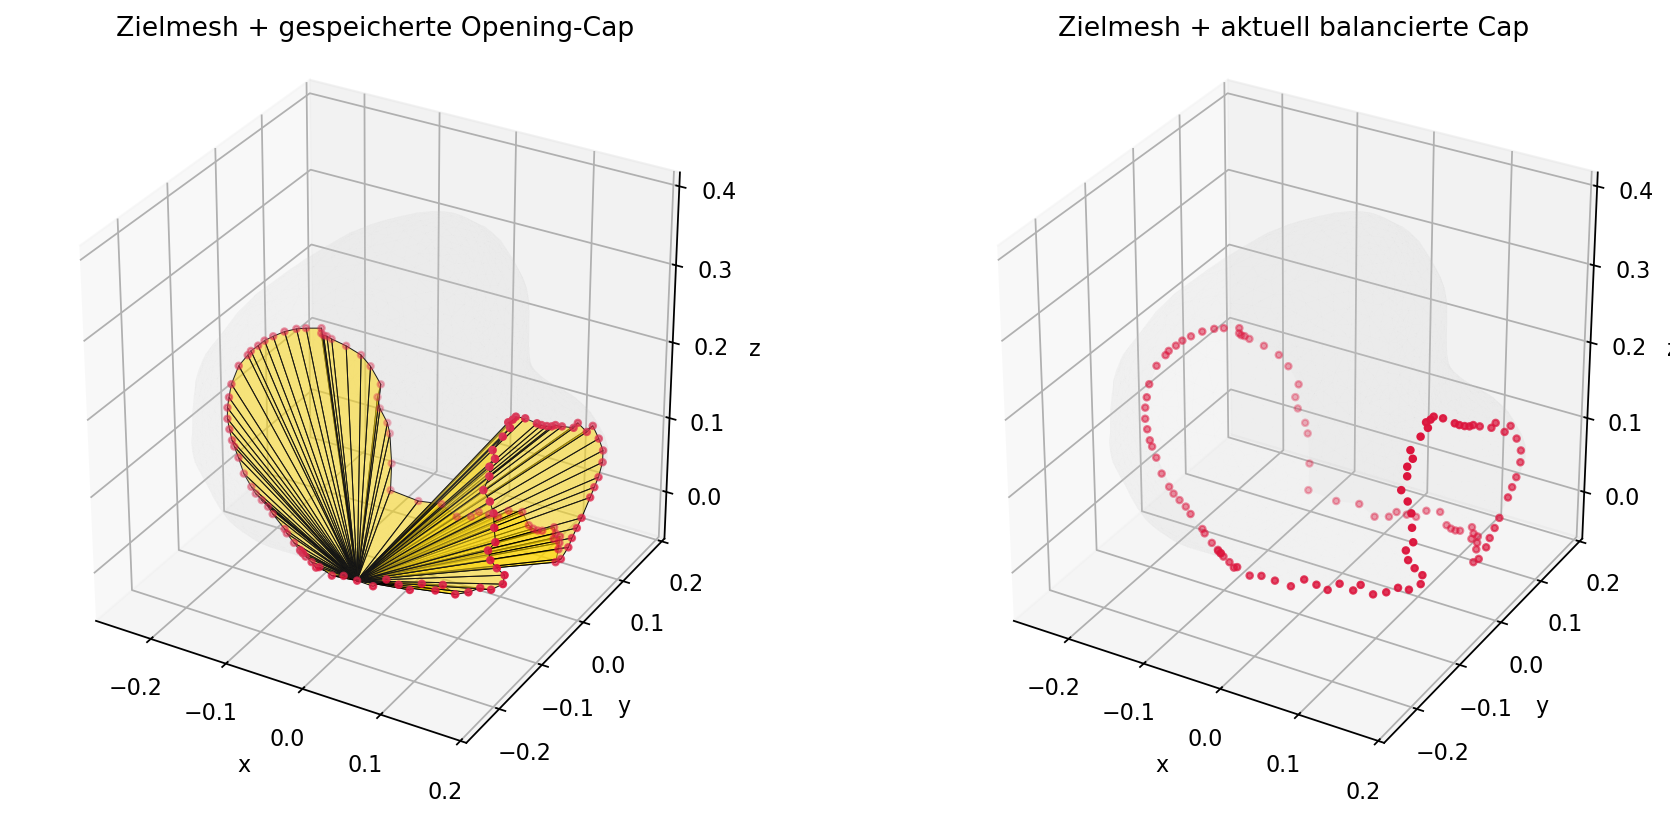

In [ ]:
def draw_scene_with_mesh(ax, mesh_verts, mesh_faces, opening_verts, opening_faces, title):
    tris_mesh = mesh_verts[np.asarray(mesh_faces, dtype=np.int64)]
    coll_mesh = Poly3DCollection(tris_mesh, facecolors='lightgray', edgecolors='none', alpha=0.5)
    ax.add_collection3d(coll_mesh)
    tris_open = opening_verts[np.asarray(opening_faces, dtype=np.int64)]
    coll_open = Poly3DCollection(tris_open, facecolors='gold', edgecolors='black', linewidths=0.45, alpha=0.55)
    ax.add_collection3d(coll_open)
    ax.scatter(opening_verts[:,0], opening_verts[:,1], opening_verts[:,2], s=8, c='crimson')
    mins = np.min(np.concatenate([mesh_verts, opening_verts], axis=0), axis=0)
    maxs = np.max(np.concatenate([mesh_verts, opening_verts], axis=0), axis=0)
    c = 0.5 * (mins + maxs)
    half = 0.55 * max(float(np.max(maxs - mins)), 1e-3)
    ax.set_xlim(c[0]-half, c[0]+half)
    ax.set_ylim(c[1]-half, c[1]+half)
    ax.set_zlim(c[2]-half, c[2]+half)
    ax.set_box_aspect((1,1,1))
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

fig = plt.figure(figsize=(12, 5), dpi=160)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
draw_scene_with_mesh(ax1, mesh_verts, mesh_faces, verts, faces_bad, 'Zielmesh + gespeicherte Opening-Cap')
faces_bal_preview = _triangulate_polygon_2d_balanced(loop_2d)
draw_scene_with_mesh(ax2, mesh_verts, mesh_faces, verts, faces_bal_preview, 'Zielmesh + aktuell balancierte Cap')
plt.tight_layout()
plt.show()


In [ ]:
def fan_ratio(faces, n_verts):
    counts = np.bincount(np.asarray(faces, dtype=np.int64).reshape(-1), minlength=n_verts)
    return float(counts.max()) / max(int(len(faces)), 1), counts

def planarity_rms(verts):
    x = verts - verts.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(x, full_matrices=False)
    dist = np.abs(x @ vh[-1])
    return float(np.sqrt(np.mean(dist ** 2))), vh[-1]

def rim_edge_cv(verts):
    ring = np.concatenate([verts, verts[:1]], axis=0)
    lens = np.linalg.norm(ring[1:] - ring[:-1], axis=1)
    return float(lens.std() / (lens.mean() + 1e-12)), lens

def tri_quality(faces, verts):
    tris = verts[np.asarray(faces, dtype=np.int64)]
    a = np.linalg.norm(tris[:, 1] - tris[:, 0], axis=1)
    b = np.linalg.norm(tris[:, 2] - tris[:, 1], axis=1)
    c = np.linalg.norm(tris[:, 0] - tris[:, 2], axis=1)
    area = 0.5 * np.linalg.norm(np.cross(tris[:, 1] - tris[:, 0], tris[:, 2] - tris[:, 0]), axis=1)
    return (4.0 * np.sqrt(3.0) * area) / (a * a + b * b + c * c + 1e-12)

fan_bad, counts_bad = fan_ratio(faces_bad, len(verts))
pl_rms, pl_normal = planarity_rms(verts)
cv_rim, rim_lens = rim_edge_cv(verts)
poly = Polygon(loop_2d)
area_2d = abs(_signed_area_2d(loop_2d))
rim_radius = np.sqrt(area_2d / np.pi) if area_2d > 1e-12 else 1.0
planarity_rel = pl_rms / max(rim_radius, 1e-6)
q_bad = tri_quality(faces_bad, verts)

print(f'fan_ratio_bad          = {fan_bad:.3f}')
print(f'planarity_rms          = {pl_rms:.6f}')
print(f'planarity_rel          = {planarity_rel:.3f}')
print(f'rim_edge_cv            = {cv_rim:.3f}')
print(f'min_triangle_quality   = {q_bad.min():.3f}')
print(f'mean_triangle_quality  = {q_bad.mean():.3f}')
print(f'polygon_is_valid       = {poly.is_valid}')
print(f'polygon_validity_msg   = {explain_validity(poly)}')
print(f'2d_area                = {area_2d:.6f}')
print('hub_vertex_bad:', int(np.argmax(counts_bad)), 'used_in_faces:', int(counts_bad.max()))


In [ ]:
def draw_mesh(ax, verts, faces, title, color='lightgray', alpha=0.5, edge='k', lw=0.5):
    tris = verts[np.asarray(faces, dtype=np.int64)]
    coll = Poly3DCollection(tris, facecolors=color, edgecolors=edge, linewidths=lw, alpha=alpha)
    ax.add_collection3d(coll)
    mins = verts.min(axis=0)
    maxs = verts.max(axis=0)
    c = 0.5 * (mins + maxs)
    half = 0.55 * max(float(np.max(maxs - mins)), 1e-3)
    ax.set_xlim(c[0]-half, c[0]+half)
    ax.set_ylim(c[1]-half, c[1]+half)
    ax.set_zlim(c[2]-half, c[2]+half)
    ax.set_box_aspect((1,1,1))
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

fig = plt.figure(figsize=(12, 5), dpi=160)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
draw_mesh(ax1, verts, faces_bad, f'{CASE_NAME}: gespeicherte Opening-Cap', color='silver', alpha=0.55)
ax1.scatter(verts[:,0], verts[:,1], verts[:,2], s=10, c='crimson')
hub = int(np.argmax(counts_bad))
ax1.scatter([verts[hub,0]], [verts[hub,1]], [verts[hub,2]], s=60, c='gold', edgecolors='black')
ax2.scatter(verts[:,0], verts[:,1], verts[:,2], s=14, c=np.arange(len(verts)), cmap='viridis')
for i, p in enumerate(verts):
    if i % max(len(verts)//24, 1) == 0:
        ax2.text(p[0], p[1], p[2], str(i), fontsize=7)
ax2.quiver(center[0], center[1], center[2], normal[0], normal[1], normal[2], length=0.15, color='black')
draw_mesh(ax2, verts, faces_bad, 'Ring + Hub-Vertex', color='lightsteelblue', alpha=0.12, edge='dimgray', lw=0.4)
plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), dpi=160)
ax[0].plot(loop_2d[:, 0], loop_2d[:, 1], '-o', ms=3)
for i, p in enumerate(loop_2d):
    if i % max(len(loop_2d)//30, 1) == 0:
        ax[0].text(p[0], p[1], str(i), fontsize=7)
ax[0].set_title('2D-Projektion des Ostium-Rings')
ax[0].axis('equal')
ax[0].grid(True, alpha=0.25)

ax[1].hist(rim_lens, bins=24, color='tab:blue', alpha=0.8)
ax[1].set_title(f'Rim edge lengths | CV={cv_rim:.3f}')
ax[1].set_xlabel('edge length')
ax[1].set_ylabel('count')
ax[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
def triangulate_polygon_2d_balanced_debug(poly):
    poly = np.asarray(poly, dtype=np.float64).reshape(-1, 2)
    info = {'n': int(poly.shape[0])}
    if poly.shape[0] < 3:
        info['stage'] = 'too_few_points'
        return np.zeros((0, 3), dtype=np.int64), info

    polygon = Polygon(poly)
    info['polygon_valid_before'] = bool(polygon.is_valid)
    info['polygon_validity_msg'] = explain_validity(polygon)
    info['polygon_area_before'] = float(polygon.area)

    if not polygon.is_valid:
        polygon = polygon.buffer(0)
        info['buffer0_used'] = True
    else:
        info['buffer0_used'] = False

    info['polygon_empty_after'] = bool(polygon.is_empty)
    info['polygon_area_after'] = float(polygon.area) if not polygon.is_empty else 0.0
    if polygon.is_empty or float(polygon.area) <= 1e-12:
        info['stage'] = 'degenerate_polygon'
        return np.zeros((0, 3), dtype=np.int64), info

    coord_to_idx = {tuple(np.round(p, 12)): int(i) for i, p in enumerate(poly)}
    orientation = 1.0 if _signed_area_2d(poly) > 0 else -1.0
    faces = []
    seen = set()
    rejected_outside = 0
    rejected_map = 0
    rejected_dup = 0

    tris = list(shapely_triangulate(polygon))
    info['triangles_from_shapely'] = len(tris)
    for tri in tris:
        rep = tri.representative_point()
        if not polygon.buffer(1e-9).covers(rep):
            rejected_outside += 1
            continue
        coords = np.asarray(tri.exterior.coords[:-1], dtype=np.float64)
        if coords.shape != (3, 2):
            rejected_map += 1
            continue
        idx = []
        ok = True
        for p in coords:
            key = tuple(np.round(p, 12))
            mapped = coord_to_idx.get(key)
            if mapped is None:
                dist = np.linalg.norm(poly - p.reshape(1, 2), axis=1)
                mapped = int(np.argmin(dist))
                if float(dist[mapped]) > 1e-7:
                    ok = False
                    break
            idx.append(int(mapped))
        if not ok or len(set(idx)) != 3:
            rejected_map += 1
            continue
        face = np.asarray(idx, dtype=np.int64)
        tri2 = poly[face]
        cross_z = float((tri2[1,0]-tri2[0,0])*(tri2[2,1]-tri2[0,1]) - (tri2[1,1]-tri2[0,1])*(tri2[2,0]-tri2[0,0]))
        if orientation * cross_z < 0.0:
            face = face[[0,2,1]]
        key = tuple(sorted(int(v) for v in face.tolist()))
        if key in seen:
            rejected_dup += 1
            continue
        seen.add(key)
        faces.append(face.tolist())

    faces_arr = np.asarray(faces, dtype=np.int64).reshape(-1, 3)
    info['accepted_faces'] = int(faces_arr.shape[0])
    info['rejected_outside'] = int(rejected_outside)
    info['rejected_map'] = int(rejected_map)
    info['rejected_dup'] = int(rejected_dup)
    info['expected_faces'] = int(poly.shape[0] - 2)

    if faces_arr.shape[0] >= (poly.shape[0] - 2):
        info['stage'] = 'balanced_success'
        return faces_arr, info

    faces_ear = _earclip_triangulate_2d(poly)
    info['earclip_faces'] = int(faces_ear.shape[0])
    if faces_ear.shape[0] > 0:
        info['stage'] = 'earclip_fallback'
        return faces_ear, info

    info['stage'] = 'explicit_fan_fallback'
    faces_fan = np.asarray([[0, i, i + 1] for i in range(1, poly.shape[0] - 1)], dtype=np.int64)
    return faces_fan, info

faces_balanced, dbg = triangulate_polygon_2d_balanced_debug(loop_2d)
faces_fan = np.asarray([[0, i, i+1] for i in range(1, len(loop_2d)-1)], dtype=np.int64)
faces_ear = _earclip_triangulate_2d(loop_2d)
dbg


In [ ]:
fan_balanced, counts_balanced = fan_ratio(faces_balanced, len(verts))
fan_ear, counts_ear = fan_ratio(faces_ear, len(verts)) if len(faces_ear) else (np.nan, np.array([]))
fan_fan, counts_fan = fan_ratio(faces_fan, len(verts))

fig = plt.figure(figsize=(16, 5), dpi=160)
for i, (faces, title, color) in enumerate([
    (faces_bad, f'Gespeichert | fan_ratio={fan_bad:.3f}', 'silver'),
    (faces_balanced, f'Aktuell balanced | fan_ratio={fan_balanced:.3f}', 'mediumseagreen'),
    (faces_fan, f'Expliziter Fan-Fallback | fan_ratio={fan_fan:.3f}', 'salmon'),
]):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    draw_mesh(ax, verts, faces, title, color=color, alpha=0.55)
plt.tight_layout()
plt.show()


## Interpretation

Woran man im Notebook erkennt, dass ein Case problematisch ist:

- `fan_ratio` ist hoch: ein Vertex haengt in sehr vielen Faces
- `planarity_rel` ist hoch: der Ring ist fuer eine saubere Cap zu unplanar
- `rim_edge_cv` ist hoch: der Ring ist ungleichmaessig gesampelt oder schlecht sortiert
- `min_triangle_quality` ist sehr klein: Sliver-Dreiecke
- `mesh`: wenn schon die gespeicherte Opening-Cap im Zielmesh fan-artig, geknickt oder unruhig aussieht, liegt das Problem vor dem Fitting im vorbereiteten Opening-Checkpoint

Woran man erkennt, wann welcher Modus verwendet wird:

- `balanced_success`: Shapely-Triangulation liefert genug gueltige Faces
- `earclip_fallback`: die balancierte Triangulation war unvollstaendig, Ear-Clipping musste einspringen
- `explicit_fan_fallback`: selbst Ear-Clipping konnte nichts Brauchbares liefern, dann entsteht der sternfoermige Fan explizit

Hinweis: Bei alten vorbereiteten Cases kann `Gespeichert` deutlich schlechter aussehen als `Aktuell balanced`. Dann ist der gespeicherte Checkpoint alt oder mit dem alten Fallback entstanden.


In [ ]:
# Optional: anderen Fall ausprobieren
# CASE_NAME = 'item_Case17'
# CKPT = ROOT / CASE_NAME / 'opa_checkpoint_1op.pkl'
# ... dann die Zellen ab dem Laden erneut ausfuehren.
